In [ ]:
!git clone https://github.com/dave123981/commerce-recommendation-engine.git
%cd commerce-recommendation-engine
!pip install -r requirements.txt -q


In [ ]:
!pwd

In [ ]:
!pip install -r requirements.txt

In [ ]:
!pip install -q kagglehub
import kagglehub

!python data/download_data.py
!python data/build_interactions.py

In [ ]:
import pandas as pd

interactions = pd.read_csv("data/interactions.csv", parse_dates=["timestamp"])

print(interactions.shape)
print(interactions.nunique())
print("sparsity:", 1 - len(interactions) / (interactions.user_id.nunique() * interactions.item_id.nunique()))
print("orders per user:", interactions.groupby("user_id").order_id.nunique().describe())
print("purchases per item:", interactions.groupby("item_id").order_id.nunique().describe())

In [ ]:
import data.build_interactions as bi
interactions = bi.build_interactions(min_orders_per_user=10, min_purchases_per_item=50)
interactions.to_csv("data/interactions.csv", index=False)

In [ ]:

from src.metrics import time_based_split

train, test = time_based_split(interactions, test_frac=0.2)
train.to_csv("data/train.csv", index=False)
test.to_csv("data/test.csv", index=False)
print(len(train), len(test))

22297249 5520463


In [1]:
import csv
with open("results.csv", "a", newline="") as f:
    csv.writer(f).writerow(["Model", "precision@10", "recall@10", "map@10", "ndcg@10"])

In [ ]:
from src.v1_popularity import PopularityRecommender
from src.metrics import evaluate_model

model = PopularityRecommender(half_life_days=30).fit(train)
metrics = evaluate_model(model, test, k=10)
print(metrics)

{'precision@10': 0.042816720496663165, 'recall@10': 0.014891039007152738, 'map@10': 0.017301025888708167, 'ndcg@10': 0.04700983159132022}


In [2]:
with open("results.csv", "a", newline="") as f:
    csv.writer(f).writerow(["v1_popularity", 0.0428,0.0139,0.0173,0.0470])

In [ ]:
from src.v2_association import AssociationRecommender
from src.metrics import evaluate_model

model_v2 = AssociationRecommender(min_support=0.001, min_confidence=0.2, min_lift=1.1).fit(train)
n_items_with_rules = len(model_v2._rules_map)
print(f"items with rules: {n_items_with_rules} / {train.item_id.nunique()}")
metrics_v2 = evaluate_model(model_v2, test, k=10)
print(metrics_v2)

items with rules: 16 / 24865
{'precision@10': 0.04256447964853821, 'recall@10': 0.015004247028310415, 'map@10': 0.01666664660856412, 'ndcg@10': 0.046052305999124916}


In [3]:
with open("results.csv", "a", newline="") as f:
    csv.writer(f).writerow(["v2_association", 0.0423,0.0150,0.0167,0.0461])

In [ ]:
from src.v3_collaborative import CollaborativeRecommender
from src.metrics import evaluate_model

model_v3 = CollaborativeRecommender(n_neighbors=20).fit(train)
metrics_v3 = evaluate_model(model_v3, test, k=10)
print(metrics_v3)



{'precision@10': 0.05130262386328732, 'recall@10': 0.01855248251402882, 'map@10': 0.021867570341040896, 'ndcg@10': 0.05720287551934992}


In [4]:
with open("results.csv", "a", newline="") as f:
    csv.writer(f).writerow(["v3_collaborative", 0.0513,0.0186,0.0219,0.0572])

In [ ]:
from src.v4_matrix_factorization import MatrixFactorizationRecommender
from src.metrics import evaluate_model

model_v4 = MatrixFactorizationRecommender(n_factors=50).fit(train)
metrics_v4 = evaluate_model(model_v4, test, k=10)
print(metrics_v4)

{'precision@10': 0.035943855468786354, 'recall@10': 0.013280267672532597, 'map@10': 0.013930269087156713, 'ndcg@10': 0.03899983213798212}


In [5]:
with open("results.csv", "a", newline="") as f:
    csv.writer(f).writerow(["v4_matrix_factorization",0.0359,0.0133,0.0139,0.0390])

In [ ]:
from src.v5_neural import NeuralRecommender
from src.metrics import evaluate_model

model_v5 = NeuralRecommender(embedding_dim=32, epochs=10).fit(train)
metrics_v5 = evaluate_model(model_v5, test, k=10)
print(metrics_v5)

Epoch 1/10
75161/75161 ━━━━━━━━━━━━━━━━━━━━ 324s 4ms/step - accuracy: 0.8845 - loss: 0.2711 - val_accuracy: 0.8909 - val_loss: 0.2524
Epoch 2/10
75161/75161 ━━━━━━━━━━━━━━━━━━━━ 310s 4ms/step - accuracy: 0.8946 - loss: 0.2432 - val_accuracy: 0.8951 - val_loss: 0.2438
Epoch 3/10
75161/75161 ━━━━━━━━━━━━━━━━━━━━ 307s 4ms/step - accuracy: 0.8999 - loss: 0.2320 - val_accuracy: 0.8966 - val_loss: 0.2398
Epoch 4/10
75161/75161 ━━━━━━━━━━━━━━━━━━━━ 307s 4ms/step - accuracy: 0.9035 - loss: 0.2243 - val_accuracy: 0.8974 - val_loss: 0.2382
Epoch 5/10
75161/75161 ━━━━━━━━━━━━━━━━━━━━ 297s 4ms/step - accuracy: 0.9063 - loss: 0.2186 - val_accuracy: 0.8980 - val_loss: 0.2371
Epoch 6/10
75161/75161 ━━━━━━━━━━━━━━━━━━━━ 306s 4ms/step - accuracy: 0.9084 - loss: 0.2141 - val_accuracy: 0.8984 - val_loss: 0.2362
Epoch 7/10
75161/75161 ━━━━━━━━━━━━━━━━━━━━ 306s 4ms/step - accuracy: 0.9102 - loss: 0.2106 - val_accuracy: 0.8983 - val_loss: 0.2362
Epoch 8/10
75161/75161 ━━━━━━━━━━━━━━━━━━━━ 304s 4ms/step - ac

In [6]:
with open("results.csv", "a", newline="") as f:
    csv.writer(f).writerow(["v5_neural",0.0500,0.0181,0.0212,0.0560])

In [7]:
import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [8]:
RESULTS_CSV = Path("results.csv")
OUTPUT_PATH = Path("version_comparison.png")

# consistent color-per-version across chart regenerations
VERSION_COLORS = {
    "v1_popularity": "#94a3b8",
    "v2_association": "#f87171",
    "v3_collaborative": "#34d399",
    "v4_matrix_factorization": "#60a5fa",
    "v5_neural": "#a78bfa",
}
VERSION_LABELS = {
    "v1_popularity": "V1 Popularity",
    "v2_association": "V2 Association",
    "v3_collaborative": "V3 Collaborative",
    "v4_matrix_factorization": "V4 Matrix Fact.",
    "v5_neural": "V5 Neural",
}
METRIC_LABELS = {
    "precision@10": "Precision@10",
    "recall@10": "Recall@10",
    "map@10": "MAP@10",
    "ndcg@10": "NDCG@10",
}

In [9]:
if not RESULTS_CSV.exists():
    raise FileNotFoundError(
        f"{RESULTS_CSV} not found. Run each version's fit + evaluate_model() cell "
        "and log a row to results.csv first (see README quickstart)."
    )

df = pd.read_csv(RESULTS_CSV)
df

,Model,precision@10,recall@10,map@10,ndcg@10
0,v1_popularity,0.0428,0.0139,0.0173,0.0470
1,v2_association,0.0423,0.0150,0.0167,0.0461
2,v3_collaborative,0.0513,0.0186,0.0219,0.0572
3,v4_matrix_factorization,0.0359,0.0133,0.0139,0.0390
4,v5_neural,0.0500,0.0181,0.0212,0.0560


saved to version_comparison.png


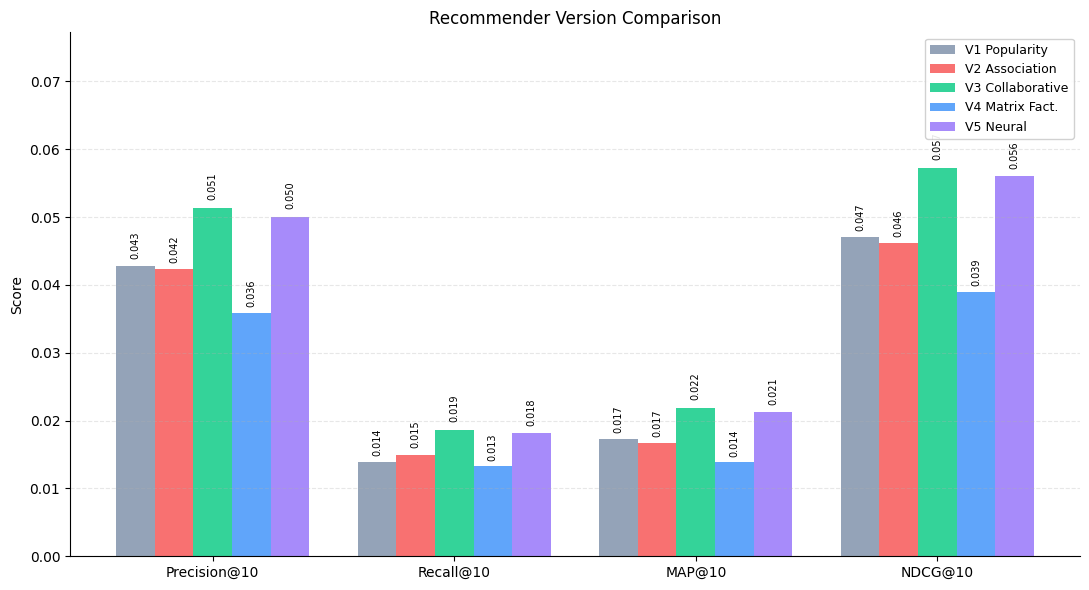

In [12]:
metrics = [c for c in df.columns if c != "Model"]

versions = df["Model"].tolist()
labels = [VERSION_LABELS.get(v, v) for v in versions]
colors = [VERSION_COLORS.get(v, "#999999") for v in versions]

fig, ax = plt.subplots(figsize=(11, 6))
n_versions = len(versions)
n_metrics = len(metrics)
bar_width = 0.8 / max(n_versions, 1)
x = np.arange(n_metrics)

for i, (version, label, color) in enumerate(zip(versions, labels, colors)):
    values = df.loc[df["Model"] == version, metrics].values.flatten()
    offset = (i - (n_versions - 1) / 2) * bar_width
    bars = ax.bar(x + offset, values, bar_width, label=label, color=color)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7, rotation=90,
        )

ax.set_ylabel("Score")
ax.set_title("Recommender Version Comparison")
ax.set_xticks(x)
ax.set_xticklabels([METRIC_LABELS.get(m, m) for m in metrics])
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.set_ylim(0, df[metrics].values.max() * 1.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=200, bbox_inches="tight")
print(f"saved to {OUTPUT_PATH}")
plt.show()